In [ ]:
"""
Full_Geom_4fold.py

PINN for Steady-State Heat Equation on Full Annulus
====================================================
4-fold reflection symmetry encoded directly in the network architecture.

Domain: Full annulus, R1 <= r <= R2
PDE: nabla^2 T = 0 (Laplace equation)
BCs:
  - Inner arc (r = R1): T = T_cold (Dirichlet)
  - Outer arc (r = R2): T = T_hot  (Dirichlet)

Symmetry encoding:
  The network forward pass averages over the 4-element orbit of (x,y)
  under reflection across both axes:
      T(x,y) = [N(x,y) + N(-x,y) + N(x,-y) + N(-x,-y)] / 4
  where N is the raw network output.

  This enforces EXACTLY:
      T(x,y)  = T(-x,y)   [reflection across y-axis]
      T(x,y)  = T(x,-y)   [reflection across x-axis]
      T(x,y)  = T(-x,-y)  [180-degree rotation]

  Consequences that hold EXACTLY by construction:
      dT/dx|_{x=0} = 0    [Neumann BC on y-axis]
      dT/dy|_{y=0} = 0    [Neumann BC on x-axis]

  Note: 4-fold reflection symmetry is NOT the same as full rotational
  symmetry T=T(r). It suppresses cos(2theta), cos(4theta), ... modes
  exactly, but cos(theta), cos(3theta), ... modes are still possible.
  For this problem the exact solution T=T(r) has full rotational symmetry,
  so the 4-fold constraint is an architectural bias toward the correct
  solution, not an exact encoding of it.

  No Neumann BCs or L_symm loss terms are needed --- the architecture
  handles symmetry enforcement exactly at zero additional loss cost.

Normalization scheme (consistent with Quarter_Geom.py and Full_Geom.py):
  - Inputs:       x_norm = x / L_char,  y_norm = y / L_char
  - Output:       T = T_mean + (T_range/2) * network_output
  - PDE loss:     laplacian / (T_range / L_char^2)   -> dimensionless
  - Dirichlet BC: (T - T_target) / T_range           -> dimensionless

Training strategy (matches Full_Geom.py):
  1. Adam optimizer with cosine annealing LR schedule
  2. L-BFGS optimizer for fine-tuning
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
import time
from typing import Tuple

# =============================================================================
# CONFIGURATION
# =============================================================================

In [ ]:
class Config:
    """Configuration container for full annulus with 4-fold symmetry."""

    def __init__(
        self,
        R1: float = 1.0,
        R2: float = 3.0,
        T_cold: float = 100.0,
        T_hot: float = 500.0,
        hidden_layers: int = 4,
        neurons_per_layer: int = 32,
        adam_iterations: int = 10000,
        lbfgs_iterations: int = 3000,
        adam_lr: float = 1e-3,
        lambda_pde: float = 1.0,
        lambda_bc: float = 10.0,
        # Full geometry point counts (matching Full_Geom.py)
        n_interior: int = 2000,
        n_boundary_inner: int = 300,
        n_boundary_outer: int = 300,
        batch_size: int = 512,
        resample_every: int = 100,
        device: str = "cuda" if torch.cuda.is_available() else "cpu"
    ):
        # Geometry
        self.R1 = R1
        self.R2 = R2

        # Boundary conditions
        self.T_cold = T_cold
        self.T_hot = T_hot

        # Network architecture
        self.hidden_layers = hidden_layers
        self.neurons_per_layer = neurons_per_layer

        # Training parameters
        self.adam_iterations = adam_iterations
        self.lbfgs_iterations = lbfgs_iterations
        self.adam_lr = adam_lr

        # Loss weights (no lambda_symm needed — symmetry is architectural)
        self.lambda_pde = lambda_pde
        self.lambda_bc = lambda_bc

        # Sampling points (full geometry counts)
        self.n_interior = n_interior
        self.n_boundary_inner = n_boundary_inner
        self.n_boundary_outer = n_boundary_outer

        # Training settings
        self.batch_size = batch_size
        self.resample_every = resample_every
        self.device = device

        # Derived normalization quantities (consistent with Full_Geom.py)
        self.T_range = T_hot - T_cold
        self.T_mean  = (T_hot + T_cold) / 2.0
        self.L_char  = R2

    def __repr__(self):
        return f"""
Configuration (Full Annulus + 4-fold Symmetry Architecture):
--------------------------------------------------------------
Geometry: R1={self.R1}, R2={self.R2}
BCs: T_cold={self.T_cold}, T_hot={self.T_hot}
Network: {self.hidden_layers} layers x {self.neurons_per_layer} neurons
Symmetry: 4-fold reflection encoded in architecture (no loss term)
Training: Adam({self.adam_iterations}) -> L-BFGS({self.lbfgs_iterations})
Weights: lambda_pde={self.lambda_pde}, lambda_bc={self.lambda_bc}
Points: interior={self.n_interior}, inner={self.n_boundary_inner}, outer={self.n_boundary_outer}
Device: {self.device}
"""

# =============================================================================
# NEURAL NETWORK WITH 4-FOLD SYMMETRY
# =============================================================================

In [ ]:

class PINN(nn.Module):
    """
    PINN with 4-fold reflection symmetry encoded in the forward pass.

    The raw network N(x,y) is an unconstrained 2-input MLP.
    The symmetrized output is:
        T(x,y) = T_mean + (T_range/2) * [N(x,y) + N(-x,y) + N(x,-y) + N(-x,-y)] / 4

    This averaging over the 4-element reflection group enforces:
        T(x,y) = T(-x,y) = T(x,-y) = T(-x,-y)  exactly, for all inputs.

    Architecture is otherwise identical to Full_Geom.py and Quarter_Geom.py:
    - Same layer structure and activation
    - Same weight initialization
    - Same input normalization (divide by L_char)
    - Same output scaling (T_mean + T_range/2 * output)

    Note on parameter count: identical to the non-symmetric version since
    we reuse the same network N four times — no extra parameters.
    The cost is 4x forward passes per training step.
    """

    def __init__(self, config: Config):
        super().__init__()
        self.config = config

        # Build raw network (identical structure to Full_Geom.py)
        layers = []

        # Input layer
        layers.append(nn.Linear(2, config.neurons_per_layer))
        layers.append(nn.Tanh())

        # Hidden layers
        for _ in range(config.hidden_layers - 1):
            layers.append(nn.Linear(config.neurons_per_layer, config.neurons_per_layer))
            layers.append(nn.Tanh())

        # Output layer (linear)
        layers.append(nn.Linear(config.neurons_per_layer, 1))

        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        """Xavier initialization; last layer near zero -> T starts near T_mean."""
        for m in self.network:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=1.0)
                nn.init.zeros_(m.bias)

        last_linear = list(self.network.children())[-1]
        nn.init.zeros_(last_linear.weight)
        last_linear.bias.data.fill_(0.0)

    def _network_normalized(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Evaluate raw network on normalized inputs.
        x, y must already be column vectors (N,1).
        Returns raw network output (N,1), before output scaling.
        """
        inputs = torch.cat([x / self.config.L_char,
                            y / self.config.L_char], dim=1)
        return self.network(inputs)

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Symmetrized forward pass.

        Averages raw network over all 4 orbit points:
            {(x,y), (-x,y), (x,-y), (-x,-y)}

        This is the group averaging (Reynolds averaging) over the
        Z2 x Z2 reflection group, which projects any function onto
        the subspace of functions invariant under both reflections.

        Input normalization and output scaling are applied once after
        averaging, consistent with Full_Geom.py.
        """
        if x.dim() == 1:
            x = x.unsqueeze(1)
        if y.dim() == 1:
            y = y.unsqueeze(1)

        # Evaluate network at all 4 orbit points
        # Each call uses the same weights — no extra parameters
        u1 = self._network_normalized( x,  y)   # (x,  y)
        u2 = self._network_normalized(-x,  y)   # (-x, y)
        u3 = self._network_normalized( x, -y)   # (x, -y)
        u4 = self._network_normalized(-x, -y)   # (-x,-y)

        # Reynolds average — exact group averaging over Z2 x Z2
        u_symm = (u1 + u2 + u3 + u4) / 4.0

        # Output scaling (consistent with Full_Geom.py and Quarter_Geom.py)
        return self.config.T_mean + (self.config.T_range / 2.0) * u_symm


# =============================================================================
# SAMPLER
# =============================================================================

In [ ]:
class Sampler:
    """
    Sampling utilities for full annular domain using LHS.
    Samples the complete annulus (theta in [0, 2*pi]).
    Consistent with Full_Geom.py.
    """

    def __init__(self, config: Config):
        self.config = config
        self.device = config.device

    def sample_interior_lhs(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Sample interior points using Latin Hypercube Sampling.
        Uniform area distribution over full annulus.
        """
        sampler = qmc.LatinHypercube(d=2, seed=None)
        samples = sampler.random(n=n_points)

        # Uniform area sampling
        r_squared = self.config.R1**2 + samples[:, 0] * (
            self.config.R2**2 - self.config.R1**2
        )
        r     = np.sqrt(r_squared)
        theta = samples[:, 1] * 2 * np.pi   # Full annulus

        x = r * np.cos(theta)
        y = r * np.sin(theta)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_inner(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Sample points on inner arc (r = R1), full circle, with jitter."""
        theta  = np.linspace(0, 2*np.pi, n_points, endpoint=False)
        theta += np.random.uniform(0, 2*np.pi / n_points, n_points)

        x = self.config.R1 * np.cos(theta)
        y = self.config.R1 * np.sin(theta)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_outer(self, n_points: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """Sample points on outer arc (r = R2), full circle, with jitter."""
        theta  = np.linspace(0, 2*np.pi, n_points, endpoint=False)
        theta += np.random.uniform(0, 2*np.pi / n_points, n_points)

        x = self.config.R2 * np.cos(theta)
        y = self.config.R2 * np.sin(theta)

        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(y, dtype=torch.float32, device=self.device)
        )

    def sample_all(self) -> dict:
        """Sample all training points for full annulus."""
        return {
            'interior': self.sample_interior_lhs(self.config.n_interior),
            'inner':    self.sample_boundary_inner(self.config.n_boundary_inner),
            'outer':    self.sample_boundary_outer(self.config.n_boundary_outer),
        }


# =============================================================================
# PHYSICS
# =============================================================================

In [ ]:
class Physics:
    """
    Physics computations for full annulus.

    Normalization scheme (consistent with Full_Geom.py and Quarter_Geom.py):

      Residual       |  Raw units  |  Normalization scale    |  Normalized
      ---------------|-------------|-------------------------|-------------
      PDE (Laplacian)|  T / L^2    |  T_range / L_char^2     |  O(1)
      Dirichlet BC   |  T          |  T_range                |  O(1)

    No symmetry loss term — symmetry is encoded in the architecture.
    """

    def __init__(self, config: Config, model: PINN):
        self.config = config
        self.model  = model

        # Normalization scales (consistent with Full_Geom.py)
        self.pde_scale = config.T_range / config.L_char**2
        self.T_scale   = config.T_range

    def compute_pde_residual(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Normalized Laplacian residual: (d^2T/dx^2 + d^2T/dy^2) / pde_scale.
        Consistent with Full_Geom.py.
        """
        x = x.requires_grad_(True)
        y = y.requires_grad_(True)

        u = self.model(x, y)

        du_dx = torch.autograd.grad(
            u, x, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        du_dy = torch.autograd.grad(
            u, y, grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

        d2u_dx2 = torch.autograd.grad(
            du_dx, x, grad_outputs=torch.ones_like(du_dx),
            create_graph=True, retain_graph=True
        )[0]

        d2u_dy2 = torch.autograd.grad(
            du_dy, y, grad_outputs=torch.ones_like(du_dy),
            create_graph=True, retain_graph=True
        )[0]

        laplacian = d2u_dx2 + d2u_dy2
        return laplacian / self.pde_scale

    def compute_bc_residual_inner(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Normalized Dirichlet BC at inner arc: (T - T_cold) / T_range."""
        u = self.model(x, y)
        return (u.squeeze() - self.config.T_cold) / self.T_scale

    def compute_bc_residual_outer(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Normalized Dirichlet BC at outer arc: (T - T_hot) / T_range."""
        u = self.model(x, y)
        return (u.squeeze() - self.config.T_hot) / self.T_scale


# =============================================================================
# TRAINER
# =============================================================================


In [ ]:
class Trainer:
    """Training loop: Adam -> L-BFGS. Matches Full_Geom.py structure."""

    def __init__(self, config: Config, model: PINN):
        self.config  = config
        self.model   = model
        self.sampler = Sampler(config)
        self.physics = Physics(config, model)

        self.history = {
            'total_loss': [], 'pde_loss': [],
            'bc_inner_loss': [], 'bc_outer_loss': [],
            'iterations': []
        }
        self.current_iteration = 0
        self.training_time     = 0.0

    def compute_losses(
        self, data: dict
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Compute PDE and BC loss components."""
        # PDE loss
        x_int, y_int = data['interior']
        residual = self.physics.compute_pde_residual(x_int, y_int)
        loss_pde = torch.mean(residual**2)

        # Dirichlet BC losses
        x_inner, y_inner = data['inner']
        bc_inner   = self.physics.compute_bc_residual_inner(x_inner, y_inner)
        loss_bc_inner = torch.mean(bc_inner**2)

        x_outer, y_outer = data['outer']
        bc_outer   = self.physics.compute_bc_residual_outer(x_outer, y_outer)
        loss_bc_outer = torch.mean(bc_outer**2)

        return loss_pde, loss_bc_inner, loss_bc_outer

    def compute_total_loss(
        self, loss_pde, loss_bc_inner, loss_bc_outer
    ) -> torch.Tensor:
        """Weighted sum of loss components."""
        return (
            self.config.lambda_pde * loss_pde +
            self.config.lambda_bc  * (loss_bc_inner + loss_bc_outer)
        )

    def get_minibatch(self, data: dict, batch_idx: int) -> dict:
        """Minibatch interior; boundary always uses full set."""
        bs    = self.config.batch_size
        x_int, y_int = data['interior']
        n_int = x_int.shape[0]
        start = (batch_idx * bs) % n_int
        end   = min(start + bs, n_int)

        return {
            'interior': (x_int[start:end], y_int[start:end]),
            'inner':    data['inner'],
            'outer':    data['outer'],
        }

    def record(self, total_loss, loss_pde, loss_bc_inner, loss_bc_outer):
        """Append losses to history."""
        self.current_iteration += 1
        self.history['total_loss'].append(total_loss.item())
        self.history['pde_loss'].append(loss_pde.item())
        self.history['bc_inner_loss'].append(loss_bc_inner.item())
        self.history['bc_outer_loss'].append(loss_bc_outer.item())
        self.history['iterations'].append(self.current_iteration)

    def train_adam(self):
        """Phase 1: Adam with cosine annealing."""
        optimizer = torch.optim.Adam(
            self.model.parameters(), lr=self.config.adam_lr
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.config.adam_iterations, eta_min=1e-6
        )

        print("=" * 65)
        print("Phase 1: Adam Optimization")
        print("=" * 65)

        data     = self.sampler.sample_all()
        n_batches = max(1, self.config.n_interior // self.config.batch_size)

        for iteration in range(self.config.adam_iterations):
            if iteration > 0 and iteration % self.config.resample_every == 0:
                data = self.sampler.sample_all()

            minibatch = self.get_minibatch(data, iteration % n_batches)

            optimizer.zero_grad()
            loss_pde, loss_bc_inner, loss_bc_outer = self.compute_losses(minibatch)
            total_loss = self.compute_total_loss(loss_pde, loss_bc_inner, loss_bc_outer)

            total_loss.backward()
            optimizer.step()
            scheduler.step()

            self.record(total_loss, loss_pde, loss_bc_inner, loss_bc_outer)

            if iteration % 1000 == 0 or iteration == self.config.adam_iterations - 1:
                lr = scheduler.get_last_lr()[0]
                print(f"Iter {iteration:5d} | Loss: {total_loss.item():.2e} | "
                      f"PDE: {loss_pde.item():.2e} | "
                      f"BC_in: {loss_bc_inner.item():.2e} | "
                      f"BC_out: {loss_bc_outer.item():.2e} | "
                      f"LR: {lr:.1e}")

    def train_lbfgs(self):
        """Phase 2: L-BFGS with strong Wolfe line search."""
        print("\n" + "=" * 65)
        print("Phase 2: L-BFGS Optimization")
        print("=" * 65)

        optimizer = torch.optim.LBFGS(
            self.model.parameters(),
            lr=1.0,
            max_iter=20,
            max_eval=25,
            history_size=100,
            tolerance_grad=1e-12,
            tolerance_change=1e-14,
            line_search_fn='strong_wolfe'
        )

        data      = self.sampler.sample_all()
        iteration = [0]

        def closure():
            optimizer.zero_grad()
            loss_pde, loss_bc_inner, loss_bc_outer = self.compute_losses(data)
            total_loss = self.compute_total_loss(loss_pde, loss_bc_inner, loss_bc_outer)
            total_loss.backward()

            self.record(total_loss, loss_pde, loss_bc_inner, loss_bc_outer)
            iteration[0] += 1

            if iteration[0] % 200 == 0:
                print(f"L-BFGS Iter {iteration[0]:4d} | Loss: {total_loss.item():.2e} | "
                      f"PDE: {loss_pde.item():.2e} | "
                      f"BC_in: {loss_bc_inner.item():.2e} | "
                      f"BC_out: {loss_bc_outer.item():.2e}")

            return total_loss

        for _ in range(self.config.lbfgs_iterations // 20):
            optimizer.step(closure)
            if iteration[0] % 500 == 0:
                data = self.sampler.sample_all()

    def train(self):
        """Full training pipeline: Adam then L-BFGS."""
        start_time = time.time()
        self.train_adam()
        self.train_lbfgs()
        self.training_time = time.time() - start_time

        print("\n" + "=" * 65)
        print(f"Training Complete!")
        print(f"Total time:  {self.training_time:.2f} seconds")
        print(f"Final loss:  {self.history['total_loss'][-1]:.2e}")
        print("=" * 65)




# =============================================================================
# ANALYTICS
# =============================================================================


In [ ]:

class Analytics:
    """Analytical solution and error metrics."""

    def __init__(self, config: Config):
        self.config = config

    def exact_solution(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        T(r) = T_cold + (T_hot - T_cold) * ln(r/R1) / ln(R2/R1)
        Exact solution for Laplace equation on annulus with uniform BCs.
        """
        r = torch.sqrt(x**2 + y**2)
        r = torch.clamp(r, min=self.config.R1, max=self.config.R2)
        log_ratio = torch.log(r / self.config.R1) / np.log(self.config.R2 / self.config.R1)
        return self.config.T_cold + (self.config.T_hot - self.config.T_cold) * log_ratio

    def compute_l2_error(self, model: PINN, n_test: int = 10000) -> Tuple[float, float]:
        """Absolute and relative L2 errors on interior test points."""
        model.eval()
        sampler = Sampler(self.config)
        x_test, y_test = sampler.sample_interior_lhs(n_test)

        with torch.no_grad():
            u_pred  = model(x_test, y_test).squeeze()
            u_exact = self.exact_solution(x_test, y_test)

            l2_error  = torch.sqrt(torch.mean((u_pred - u_exact)**2))
            l2_exact  = torch.sqrt(torch.mean(u_exact**2))
            rel_error = (l2_error / l2_exact).item()
            abs_error = l2_error.item()

        model.train()
        return abs_error, rel_error

    def compute_symmetry_error(self, model: PINN, n_test: int = 5000) -> dict:
        """
        Verify that 4-fold symmetry is exactly enforced by the architecture.
        Tests T(x,y) == T(-x,y), T(x,y) == T(x,-y), T(x,y) == T(-x,-y).
        All errors should be at floating-point precision (~1e-7).
        """
        model.eval()
        sampler = Sampler(self.config)
        x_test, y_test = sampler.sample_interior_lhs(n_test)

        with torch.no_grad():
            T_pp = model( x_test,  y_test).squeeze()  # (+x, +y)
            T_mp = model(-x_test,  y_test).squeeze()  # (-x, +y)
            T_pm = model( x_test, -y_test).squeeze()  # (+x, -y)
            T_mm = model(-x_test, -y_test).squeeze()  # (-x, -y)

            err_xrefl = torch.max(torch.abs(T_pp - T_mp)).item()
            err_yrefl = torch.max(torch.abs(T_pp - T_pm)).item()
            err_rot180 = torch.max(torch.abs(T_pp - T_mm)).item()

        model.train()
        return {
            'max_err_x_reflection': err_xrefl,
            'max_err_y_reflection': err_yrefl,
            'max_err_180_rotation': err_rot180,
        }



# =============================================================================
# VISUALIZATION
# =============================================================================

In [ ]:
class Visualizer:
    """Plotting utilities for full annulus with 4-fold symmetry."""

    def __init__(self, config: Config):
        self.config = config

    def _make_grid(self, n_grid: int):
        """Build meshgrid and annular mask for full domain."""
        x = np.linspace(-self.config.R2, self.config.R2, n_grid)
        y = np.linspace(-self.config.R2, self.config.R2, n_grid)
        X, Y = np.meshgrid(x, y)
        R    = np.sqrt(X**2 + Y**2)
        mask = (R >= self.config.R1) & (R <= self.config.R2)
        return X, Y, mask

    def plot_solution(self, model: PINN, analytics: Analytics, n_grid: int = 100):
        """Predicted vs exact temperature and pointwise absolute error."""
        model.eval()
        X, Y, mask = self._make_grid(n_grid)

        X_t = torch.tensor(X.flatten(), dtype=torch.float32, device=self.config.device)
        Y_t = torch.tensor(Y.flatten(), dtype=torch.float32, device=self.config.device)

        with torch.no_grad():
            U_pred  = model(X_t, Y_t).cpu().numpy().reshape(n_grid, n_grid)
            U_exact = analytics.exact_solution(X_t, Y_t).cpu().numpy().reshape(n_grid, n_grid)

        U_pred_m  = np.where(mask, U_pred,  np.nan)
        U_exact_m = np.where(mask, U_exact, np.nan)
        Error     = np.where(mask, np.abs(U_pred - U_exact), np.nan)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        vmin, vmax = self.config.T_cold, self.config.T_hot

        im1 = axes[0].contourf(X, Y, U_pred_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[0].set_title('Predicted Solution (4-fold Sym)', fontsize=14)
        axes[0].set_aspect('equal')
        plt.colorbar(im1, ax=axes[0], label='Temperature')

        im2 = axes[1].contourf(X, Y, U_exact_m, levels=50, cmap='hot', vmin=vmin, vmax=vmax)
        axes[1].set_title('Exact Solution', fontsize=14)
        axes[1].set_aspect('equal')
        plt.colorbar(im2, ax=axes[1], label='Temperature')

        im3 = axes[2].contourf(X, Y, Error, levels=50, cmap='viridis')
        axes[2].set_title('Absolute Error |T_pred - T_exact|', fontsize=14)
        axes[2].set_aspect('equal')
        plt.colorbar(im3, ax=axes[2], label='|Error|')

        theta = np.linspace(0, 2*np.pi, 200)
        for ax in axes:
            ax.plot(self.config.R1*np.cos(theta), self.config.R1*np.sin(theta), 'k-', lw=1)
            ax.plot(self.config.R2*np.cos(theta), self.config.R2*np.sin(theta), 'k-', lw=1)
            ax.set_xlabel('x')
            ax.set_ylabel('y')

        plt.suptitle('Full Annulus PINN with 4-fold Symmetry Architecture', fontsize=13)
        plt.tight_layout()
        plt.show()
        model.train()

    def plot_symmetry_verification(self, model: PINN, n_grid: int = 100):
        """
        Plot T(x,y) - T(-x,y) and T(x,y) - T(x,-y) over the domain.
        Both should be at floating-point precision if architecture is correct.
        """
        model.eval()
        X, Y, mask = self._make_grid(n_grid)

        X_t = torch.tensor( X.flatten(), dtype=torch.float32, device=self.config.device)
        Y_t = torch.tensor( Y.flatten(), dtype=torch.float32, device=self.config.device)
        Xn_t = torch.tensor(-X.flatten(), dtype=torch.float32, device=self.config.device)
        Yn_t = torch.tensor(-Y.flatten(), dtype=torch.float32, device=self.config.device)

        with torch.no_grad():
            T_pp = model( X_t,  Y_t).cpu().numpy().reshape(n_grid, n_grid)
            T_mp = model(Xn_t,  Y_t).cpu().numpy().reshape(n_grid, n_grid)
            T_pm = model( X_t, Yn_t).cpu().numpy().reshape(n_grid, n_grid)

        diff_x = np.where(mask, np.abs(T_pp - T_mp), np.nan)
        diff_y = np.where(mask, np.abs(T_pp - T_pm), np.nan)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        im1 = axes[0].contourf(X, Y, diff_x, levels=50, cmap='viridis')
        axes[0].set_title('|T(x,y) - T(-x,y)|\n(should be ~machine precision)', fontsize=12)
        axes[0].set_aspect('equal')
        plt.colorbar(im1, ax=axes[0])

        im2 = axes[1].contourf(X, Y, diff_y, levels=50, cmap='viridis')
        axes[1].set_title('|T(x,y) - T(x,-y)|\n(should be ~machine precision)', fontsize=12)
        axes[1].set_aspect('equal')
        plt.colorbar(im2, ax=axes[1])

        theta = np.linspace(0, 2*np.pi, 200)
        for ax in axes:
            ax.plot(self.config.R1*np.cos(theta), self.config.R1*np.sin(theta), 'k-', lw=1)
            ax.plot(self.config.R2*np.cos(theta), self.config.R2*np.sin(theta), 'k-', lw=1)
            ax.set_xlabel('x')
            ax.set_ylabel('y')

        plt.suptitle('4-fold Symmetry Verification (architectural enforcement)', fontsize=12)
        plt.tight_layout()
        plt.show()
        model.train()

    def plot_loss_curves(self, history: dict):
        """Training loss curves on log scale."""
        fig, ax = plt.subplots(figsize=(10, 6))

        ax.semilogy(history['iterations'], history['total_loss'],    'b-',  label='Total',    lw=2)
        ax.semilogy(history['iterations'], history['pde_loss'],      'r--', label='PDE',      alpha=0.8)
        ax.semilogy(history['iterations'], history['bc_inner_loss'], 'g-.', label='BC Inner', alpha=0.8)
        ax.semilogy(history['iterations'], history['bc_outer_loss'], 'm:',  label='BC Outer', alpha=0.8)

        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss (log scale)')
        ax.set_title('Training Loss Curves (Full Annulus + 4-fold Symmetry)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_radial_profile(self, model: PINN, analytics: Analytics, n_points: int = 100):
        """
        Temperature vs radius at multiple angles.
        For a well-trained model all curves should overlap the exact solution,
        confirming that residual angular variation is negligible.
        """
        model.eval()

        r      = np.linspace(self.config.R1, self.config.R2, n_points)
        angles = [0, np.pi/4, np.pi/2, np.pi]
        labels = ['theta=0', 'theta=pi/4', 'theta=pi/2', 'theta=pi']
        styles = ['r--', 'g:', 'm-.', 'c--']

        # Exact solution (radially symmetric)
        x0      = torch.tensor(r, dtype=torch.float32, device=self.config.device)
        y0      = torch.zeros_like(x0)
        u_exact = analytics.exact_solution(x0, y0).cpu().numpy()

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        axes[0].plot(r, u_exact, 'b-', label='Exact', lw=2.5)
        axes[1].set_yscale('log')

        for angle, label, style in zip(angles, labels, styles):
            xa = torch.tensor(r * np.cos(angle), dtype=torch.float32, device=self.config.device)
            ya = torch.tensor(r * np.sin(angle), dtype=torch.float32, device=self.config.device)
            with torch.no_grad():
                u_pred = model(xa, ya).cpu().numpy().flatten()
            axes[0].plot(r, u_pred, style, label=f'PINN ({label})', lw=1.5)
            axes[1].plot(r, np.abs(u_pred - u_exact) + 1e-12, style,
                         label=f'Error ({label})', lw=1.5)

        axes[0].set_xlabel('Radius r')
        axes[0].set_ylabel('Temperature')
        axes[0].set_title('Radial Profile at Multiple Angles')
        axes[0].legend(fontsize=8)
        axes[0].grid(True, alpha=0.3)

        axes[1].set_xlabel('Radius r')
        axes[1].set_ylabel('|Error| (log scale)')
        axes[1].set_title('Radial Error at Multiple Angles')
        axes[1].legend(fontsize=8)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        model.train()

In [ ]:
# =============================================================================
# MAIN
# =============================================================================


Configuration (Full Annulus + 4-fold Symmetry Architecture):
--------------------------------------------------------------
Geometry: R1=1.0, R2=3.0
BCs: T_cold=100.0, T_hot=500.0
Network: 4 layers x 32 neurons
Symmetry: 4-fold reflection encoded in architecture (no loss term)
Training: Adam(10000) -> L-BFGS(3000)
Weights: lambda_pde=1.0, lambda_bc=10.0
Points: interior=2000, inner=300, outer=300
Device: cpu

Model Parameters: 3,297
(Same parameter count as unconstrained network — symmetry is free)

Phase 1: Adam Optimization
Iter     0 | Loss: 5.00e+00 | PDE: 0.00e+00 | BC_in: 2.50e-01 | BC_out: 2.50e-01 | LR: 1.0e-03
Iter  1000 | Loss: 2.94e-04 | PDE: 2.77e-04 | BC_in: 1.75e-07 | BC_out: 1.61e-06 | LR: 9.8e-04
Iter  2000 | Loss: 1.70e-04 | PDE: 1.61e-04 | BC_in: 3.76e-07 | BC_out: 5.68e-07 | LR: 9.0e-04
Iter  3000 | Loss: 1.80e-04 | PDE: 1.61e-04 | BC_in: 1.26e-06 | BC_out: 6.65e-07 | LR: 7.9e-04
Iter  4000 | Loss: 8.02e-05 | PDE: 7.66e-05 | BC_in: 2.47e-07 | BC_out: 1.19e-07 | LR: 

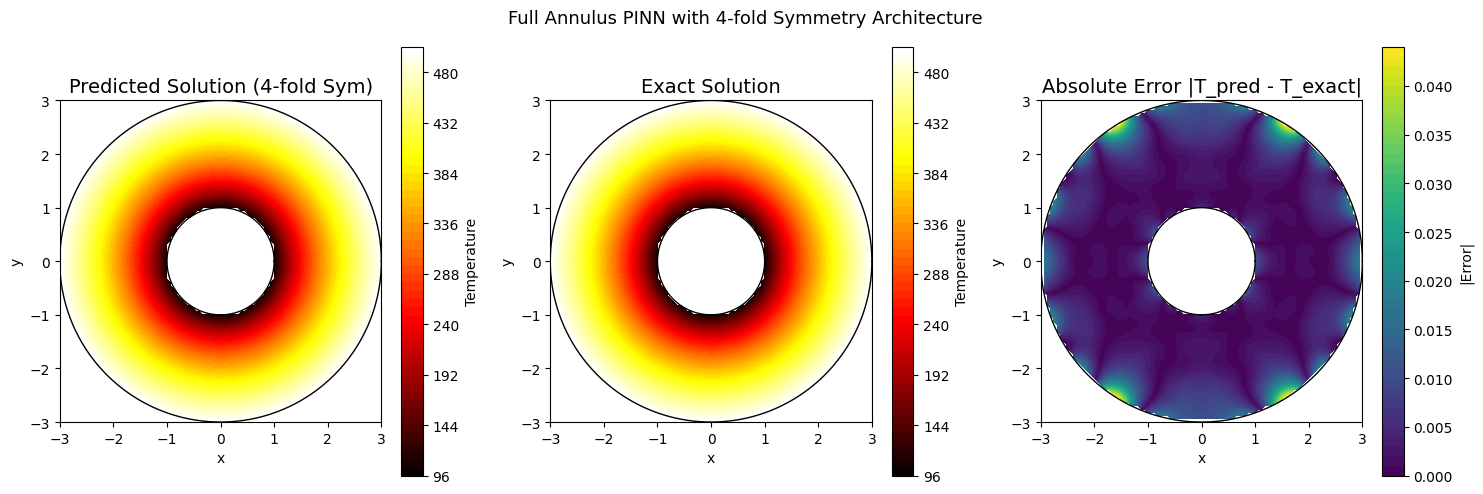

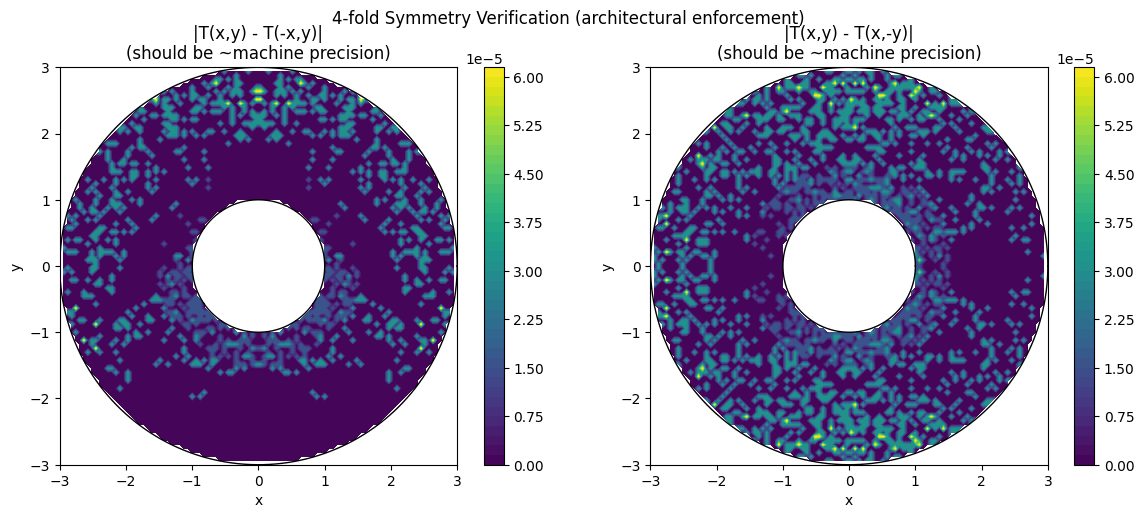

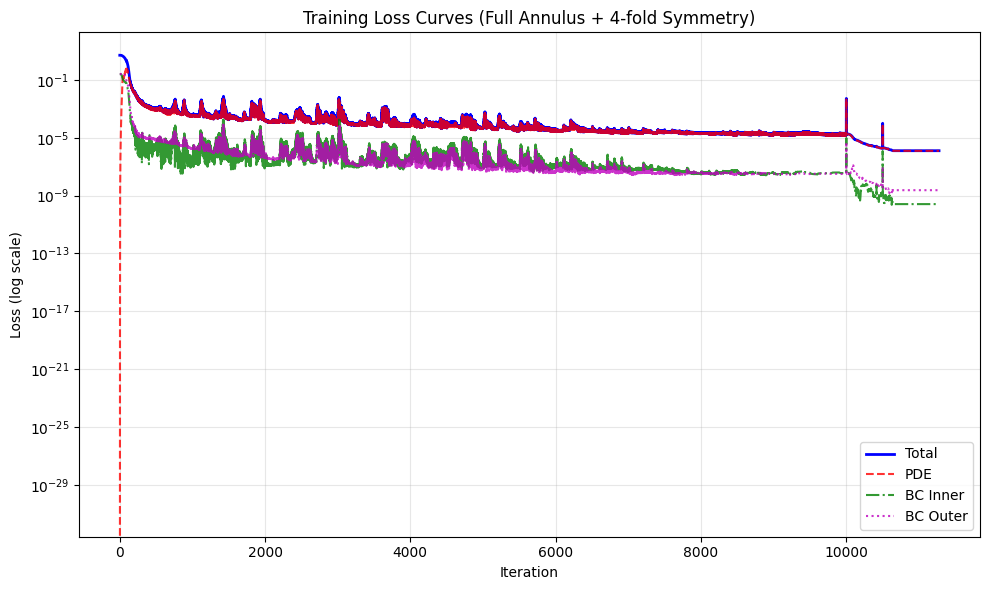

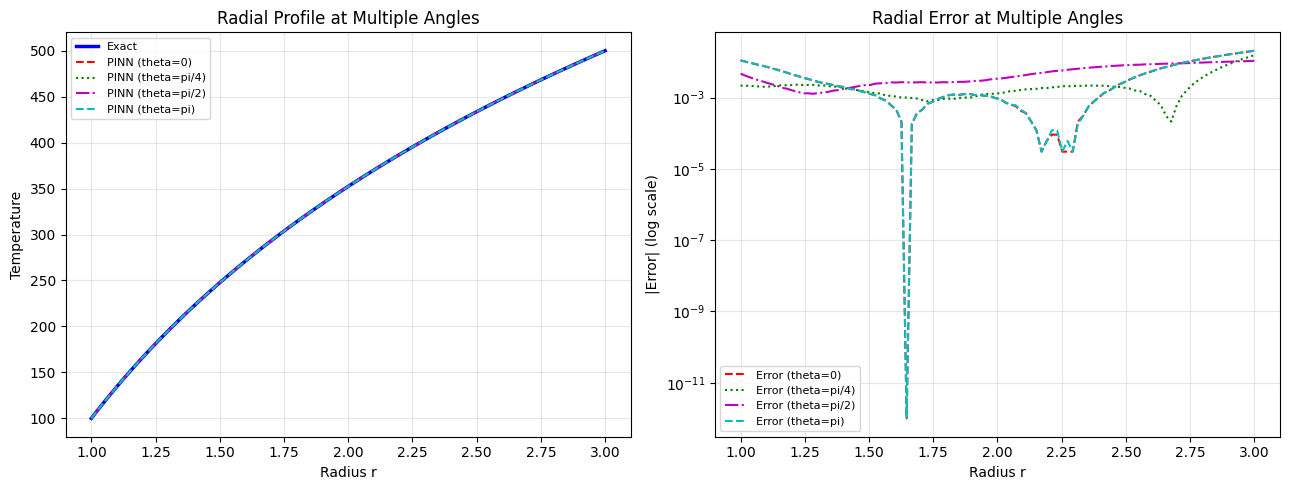

In [ ]:


def run_pinn(
    R1: float = 1.0,
    R2: float = 3.0,
    T_cold: float = 100.0,
    T_hot: float = 500.0,
    hidden_layers: int = 4,
    neurons_per_layer: int = 32,
    adam_iterations: int = 10000,
    lbfgs_iterations: int = 3000,
    lambda_pde: float = 1.0,
    lambda_bc: float = 10.0
) -> Tuple[PINN, dict, float, float]:
    """
    Run complete PINN training and visualization for full annulus
    with 4-fold reflection symmetry encoded in architecture.
    """

    config = Config(
        R1=R1, R2=R2,
        T_cold=T_cold, T_hot=T_hot,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer,
        adam_iterations=adam_iterations,
        lbfgs_iterations=lbfgs_iterations,
        lambda_pde=lambda_pde,
        lambda_bc=lambda_bc
    )

    print(config)

    model = PINN(config).to(config.device)
    print(f"Model Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"(Same parameter count as unconstrained network — symmetry is free)\n")

    trainer = Trainer(config, model)
    trainer.train()

    analytics = Analytics(config)
    abs_err, rel_err   = analytics.compute_l2_error(model)
    sym_errors         = analytics.compute_symmetry_error(model)

    print(f"\n{'='*65}")
    print(f"Error Metrics:")
    print(f"  Absolute L2 Error    : {abs_err:.4e}")
    print(f"  Relative L2 Error    : {rel_err:.4%}")
    print(f"  Training Time        : {trainer.training_time:.2f} s")
    print(f"\nSymmetry Verification (should be ~1e-7, floating-point precision):")
    print(f"  Max |T(x,y)-T(-x,y)| : {sym_errors['max_err_x_reflection']:.2e}")
    print(f"  Max |T(x,y)-T(x,-y)| : {sym_errors['max_err_y_reflection']:.2e}")
    print(f"  Max |T(x,y)-T(-x,-y)|: {sym_errors['max_err_180_rotation']:.2e}")
    print(f"{'='*65}")

    visualizer = Visualizer(config)
    visualizer.plot_solution(model, analytics)
    visualizer.plot_symmetry_verification(model)
    visualizer.plot_loss_curves(trainer.history)
    visualizer.plot_radial_profile(model, analytics)

    return model, trainer.history, abs_err, rel_err


if __name__ == "__main__":
    model, history, abs_err, rel_err = run_pinn(
        R1=1.0,
        R2=3.0,
        T_cold=100.0,
        T_hot=500.0,
        hidden_layers=4,
        neurons_per_layer=32,
        adam_iterations=10000,
        lbfgs_iterations=3000,
        lambda_pde=1.0,
        lambda_bc=10.0
    )